In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

In [ ]:
metrics_csv = './20250710_160546/merge/merge-sts-0-merge-metrics/merge_metrics.csv'  


In [ ]:
merge_folder = './20250710_160546/merge/merge-sts-0-merge-result/'  # Folder containing merged_*.csv files

In [ ]:
metrics_df = pd.read_csv(metrics_csv, parse_dates=['merge_timestamp'])

In [ ]:
metrics_df['match_key'] = metrics_df['merge_timestamp'].dt.strftime('merged_%Y%m%dT%H%M%S')

In [ ]:
print(metrics_df['match_key'])

In [60]:
os.path.join(merge_folder, 'merged_*.csv')

'./20250710_160546/merge/merge-sts-0-merge-result/merged_*.csv'

In [106]:

#  Process Merge Files and Compute Latencies

latency_summary_list = []

for file_path in glob.glob(os.path.join(merge_folder, 'merged_*.csv')):
   
    file_name = os.path.basename(file_path)
    
    try:
        df = pd.read_csv(file_path)
       
        latencies = df['end_to_end_delay_ms']

        avg_latency = latencies.mean()
        median_latency = latencies.median()
        #p95_latency = latencies.quantile(0.80)
        p90_latency = latencies.quantile(0.90)
       
        # Retrieve matching throughput from metrics_df
        file_key = os.path.splitext(file_name)[0]  # removes .csv
        throughput_row = metrics_df[metrics_df['match_key'] == file_key]
        print(throughput_row)
        if not throughput_row.empty:
            throughput = throughput_row['throughput_MBps'].values[0]
            merge_timestamp = throughput_row['merge_timestamp'].values[0]
        else:
            throughput = None
            merge_timestamp = None

        latency_summary_list.append({
            'file': file_name,
            'merge_timestamp': merge_timestamp,
            'avg_latency_ms': avg_latency,
            'median_latency_ms': median_latency,
            #'p95_latency_ms': p95_latency,
            'p90_latency_ms': p90_latency,
            'throughput_MBps': throughput
        })
    except Exception as e:
        print(f"Error processing {file_name}: {e}")





      merge_timestamp  throughput_MBps  late_rate  out_of_order_rate  \
6 2025-07-10 21:56:30          0.00277      0.804              0.272   

   duplicate_rate  batch_size_rows  batch_size_MB  uptime_seconds  \
6           0.055             1000       0.041602      112.336384   

   cpu_percent  memory_percent  ...  LINGER_MS  BATCH_SIZE  ACKS  \
6          5.5            11.5  ...          0       32768     1   

   NUM_PARTITIONS  REPLICATION_FACTOR  MIN_INSYNC_REPLICAS  CONSUMER_COUNT  \
6              10                   1                    1               1   

   FETCH_MAX_WAIT_MS  MESSAGE_SIZE_BYTES               match_key  
6                100                1024  merged_20250710T215630  

[1 rows x 22 columns]
       merge_timestamp  throughput_MBps  late_rate  out_of_order_rate  \
34 2025-07-10 22:01:07         0.002335        0.0              0.268   

    duplicate_rate  batch_size_rows  batch_size_MB  uptime_seconds  \
34           0.046              500       0.0212

In [107]:
latency_df = pd.DataFrame(latency_summary_list)

#  Save Summary CSV 
latency_df.to_csv('latency_throughput_summary_combined.csv', index=False)
print("\nSaved combined summary to 'latency_throughput_summary_combined.csv'.")


Saved combined summary to 'latency_throughput_summary_combined.csv'.


In [108]:
print(latency_df)

                          file     merge_timestamp  avg_latency_ms  \
0   merged_20250710T215630.csv 2025-07-10 21:56:30    1.041711e+06   
1   merged_20250710T220107.csv 2025-07-10 22:01:07    6.400139e+05   
2   merged_20250710T220113.csv 2025-07-10 22:01:13    8.149666e+05   
3   merged_20250710T215753.csv 2025-07-10 21:57:53    4.877073e+05   
4   merged_20250710T220058.csv 2025-07-10 22:00:58    1.053751e+06   
..                         ...                 ...             ...   
60  merged_20250710T215600.csv 2025-07-10 21:56:00    5.596295e+05   
61  merged_20250710T220334.csv 2025-07-10 22:03:34    1.196275e+06   
62  merged_20250710T220526.csv 2025-07-10 22:05:26    1.003643e+06   
63  merged_20250710T220321.csv 2025-07-10 22:03:21    1.432979e+06   
64  merged_20250710T215615.csv 2025-07-10 21:56:15    3.035080e+05   

    median_latency_ms  p90_latency_ms  throughput_MBps  
0        1.203121e+06    1.423424e+06         0.002770  
1        6.394432e+05    7.394605e+05        

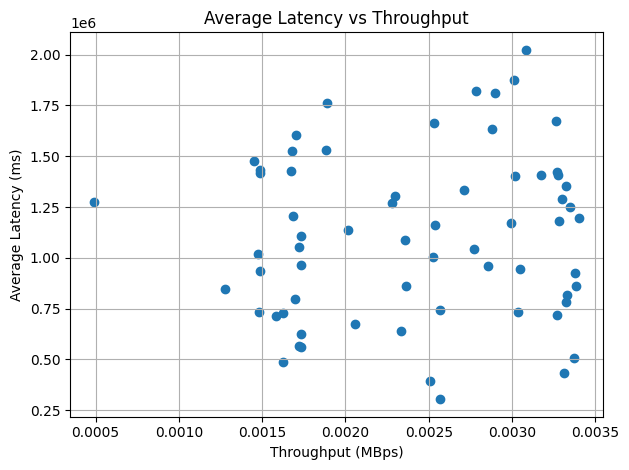


=== Correlation with Throughput ===
                 throughput_MBps  avg_latency_ms  p90_latency_ms
throughput_MBps         1.000000        0.094306        0.036437
avg_latency_ms          0.094306        1.000000        0.842746
p90_latency_ms          0.036437        0.842746        1.000000


In [111]:
#  Plot Latency vs Throughput 

plt.figure()
plt.scatter(latency_df['throughput_MBps'], latency_df['avg_latency_ms'], marker='o')
plt.xlabel('Throughput (MBps)')
plt.ylabel('Average Latency (ms)')
plt.title('Average Latency vs Throughput')
plt.grid(True)
plt.tight_layout()
plt.show()


# === 5. Optional: Correlation Analysis ===
print("\n=== Correlation with Throughput ===")
print(latency_df[['throughput_MBps', 'avg_latency_ms',  'p90_latency_ms']].corr())


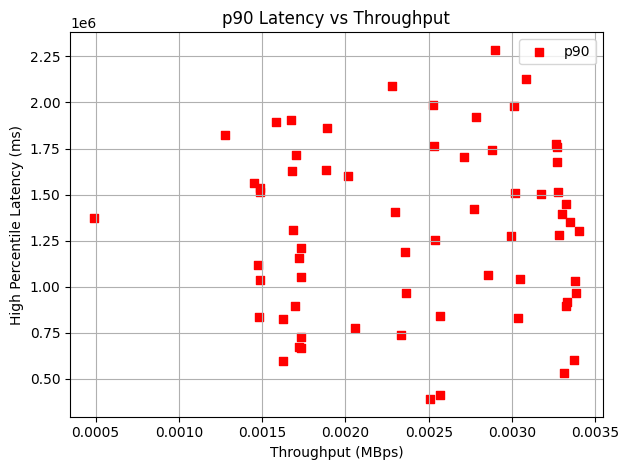

In [112]:
plt.figure()
#plt.scatter(latency_df['throughput_MBps'], latency_df['p95_latency_ms'], marker='x', color='blue', label='p95')
plt.scatter(latency_df['throughput_MBps'], latency_df['p90_latency_ms'], marker='s', color='red', label='p90')
plt.xlabel('Throughput (MBps)')
plt.ylabel('High Percentile Latency (ms)')
plt.title('p90 Latency vs Throughput')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [113]:
# === 2. Plot Latency vs TARGET_RATE ===
plt.figure()
plt.scatter(df['TARGET_RATE'], df['avg_latency_ms'], label='Avg Latency', marker='o')
plt.scatter(df['TARGET_RATE'], df['p95_latency_ms'], label='p95 Latency', marker='x')
plt.scatter(df['TARGET_RATE'], df['p99_latency_ms'], label='p99 Latency', marker='s')
plt.xlabel('TARGET_RATE (msg/sec)')
plt.ylabel('Latency (ms)')
plt.title('Latency vs TARGET_RATE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

KeyError: 'TARGET_RATE'

<Figure size 640x480 with 0 Axes>